<div style='color: #216969;
           background-color: #EAF6F6;
           font-size: 200%;
           border-radius:15px;
           text-align:center;
           font-weight:600;
           border-style: solid;
           border-color: dark green;
           font-family: "Cambria";'>
Lasso Regularization
<a class="anchor" id="1"></a> 

. You might choose Lasso over other regression techniques (e.g., Linear Regression, Ridge Regression, or Elastic Net) in the following scenarios:

-    Many Features: When you have a large number of features, and you suspect many are irrelevant or redundant.

-   Sparse Solutions Needed: When you want a model with fewer non-zero coefficients for simplicity or interpretability.

- Multicollinearity Present: When your features are correlated, and you need a model that can handle this effectively.

- Compared to Ridge: Use Lasso if you want feature selection (Ridge keeps all features but shrinks them toward zero, without eliminating them).

- Compared to Elastic Net: Use Lasso if you prefer a simpler model or don’t need the flexibility of combining L1 and L2 regularization (Elastic Net is a hybrid of Lasso and Ridge).



In [1]:
# dataset loading
import pandas as pd
df= pd.read_csv("../data/features_kept1.csv", index_col=0)

In [ ]:
df.head()

,YearBuilt,YearRemodAdd,GarageArea,GrLivArea,MasVnrArea,WoodDeckSF,PoolArea,TotalBsmtSF,ScreenPorch,BsmtFinSF1,SalePrice
0,2003.0,2003.0,548.0,1710.0,196.0,0.0,0.0,856.0,0.0,706.0,208500.0
1,1976.0,1976.0,460.0,1262.0,0.0,298.0,0.0,1262.0,0.0,978.0,181500.0
2,2001.0,2002.0,608.0,1786.0,162.0,0.0,0.0,920.0,0.0,486.0,223500.0
3,1915.0,1970.0,642.0,1717.0,0.0,0.0,0.0,756.0,0.0,216.0,140000.0
4,2000.0,2000.0,836.0,2198.0,350.0,192.0,0.0,1145.0,0.0,655.0,250000.0


In [4]:
df.isna().sum()/df.shape[0] # check for missing values

YearBuilt       0.0
YearRemodAdd    0.0
GarageArea      0.0
GrLivArea       0.0
MasVnrArea      0.0
WoodDeckSF      0.0
PoolArea        0.0
TotalBsmtSF     0.0
ScreenPorch     0.0
BsmtFinSF1      0.0
SalePrice       0.0
dtype: float64

In [6]:
df.dropna(inplace=True) # drop rows with missing values

![](../imgs/target.jpeg)

In [7]:
#Standardize the features by removing the mean and scaling to unit variance.
import numpy as np
X=df.drop("SalePrice", axis=1)
y=np.log1p(df.SalePrice)    # test 1st as df.Saleprice  then turn to log1p
# y=df.SalePrice
X.keys()

Index(['YearBuilt', 'YearRemodAdd', 'GarageArea', 'GrLivArea', 'MasVnrArea',
       'WoodDeckSF', 'PoolArea', 'TotalBsmtSF', 'ScreenPorch', 'BsmtFinSF1'],
      dtype='object')

![](https://i.ibb.co/QChD6Y4/Train-test-1.jpg)

In [8]:
# data splitting 
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test=train_test_split(X, y  ,test_size=.33, random_state=42)

## Normalization

In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Lasso 

<image src="https://static.thenounproject.com/png/2010152-200.png" width=10%></img>

$\Large  RSS_{Ridge}= \sum (Y_i -\beta_0 -\beta_iX_i )^2 + \alpha\sum|\beta_i|  $

-  Lasso regression. 
-  Lasso is a linear model that estimates sparse coefficients.
-  It is useful for feature selection in high-dimensional datasets.
-  It uses L1 regularization to penalize large coefficients.
-  Lasso regression can be used for feature selection by setting the regularization parameter alpha.
-  The larger the value of alpha, the more regularization is applied.
-  The smaller the value of alpha, the less regularization is applied.
-  Lasso regression can be used for feature selection by setting the regularization parameter alpha.
-  The larger the value of alpha, the more regularization is applied.
-  The smaller the value of alpha, the less regularization is applied.
-  Lasso regression can be used for feature selection by setting the regularization parameter alpha.
-  The larger the value of alpha, the more regularization is applied.
-  The smaller the value of alpha, the less regularization is applied.
-  Lasso regression can be used for feature selection by setting the regularization parameter alpha.

In [13]:
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=0.001) # Adjust alpha for regularization strength
lasso.fit(X_train_scaled , y_train)

Lasso(alpha=0.001)

![](../imgs/metrics.png)

In [14]:
print(f'Lasso Regression: R^2 score on training set: {lasso.score(X_train_scaled, y_train):.3f}' )

print(f'Lasso Regression: R^2 score on test set: {    lasso.score(X_test_scaled, y_test):.3f}'   )

Lasso Regression: R^2 score on training set: 0.769
Lasso Regression: R^2 score on test set: 0.811


In [15]:
from sklearn import metrics
print(f'RMSE : {np.sqrt(metrics.mean_squared_error(y_test, lasso.predict(X_test))) :.3f}  ')

RMSE : 674.981  


/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but Lasso was fitted without feature names
  warnings.warn(


In [16]:
np.expm1(0.413)

np.float64(0.5113450259339937)

In [17]:
feature_names = X.columns
coefficients = pd.DataFrame({'Feature': feature_names, 'Coefficient': lasso.coef_})
print("\nFeature Coefficients:")
coefficients.sort_values(by='Coefficient', ascending=False)


Feature Coefficients:


,Feature,Coefficient
3,GrLivArea,0.161026
0,YearBuilt,0.089416
1,YearRemodAdd,0.077512
2,GarageArea,0.073591
7,TotalBsmtSF,0.045698
8,ScreenPorch,0.036064
5,WoodDeckSF,0.025870
9,BsmtFinSF1,0.022233
4,MasVnrArea,0.003941
6,PoolArea,-0.033658


5. Practical Considerations for Deployment
Data Preprocessing: Lasso requires scaled features (e.g., using StandardScaler) because the L1 penalty is sensitive to the magnitude of input features.

Hyperparameter Tuning: Use grid search or random search with cross-validation to find the optimal alpha value.

Scalability: For very large datasets, consider using distributed computing frameworks like Dask or Spark, or leverage AWS SageMaker for scalable deployment.

Monitoring: In production, monitor for data drift, model degradation, and new feature importance over time.



In [22]:
# display highest coefficients
coefficients.sort_values(by='Coefficient', ascending=False).head(3) 

,Feature,Coefficient
3,GrLivArea,0.161026
0,YearBuilt,0.089416
1,YearRemodAdd,0.077512


# Optional

In [18]:
from sklearn.model_selection import learning_curve
from sklearn.metrics import mean_squared_error, make_scorer

mse_scorer = make_scorer(mean_squared_error, greater_is_better=False)

train_sizes, train_scores, test_scores = learning_curve(
    estimator=lasso,          # Your scikit-learn model
    X=X_train,                # Training data features
    y=y_train,                # Training data target
    train_sizes=np.linspace(0.1, 1.0, 10),  # Relative/absolute sizes of training sets
    cv=5,                     # Cross-validation strategy (e.g., 5-fold)
    scoring=mse_scorer,        # Use the scorer object (or a string like 'neg_mean_squared_error')
    n_jobs=-1,               # Use all available CPU cores
    shuffle=True,              # Shuffle the data before splitting into batches
    random_state=42,         # For reproducibility
    return_times = False,      # if True will return fit and score times
    verbose=0                  # Controls verbosity: higher values = more messages
)

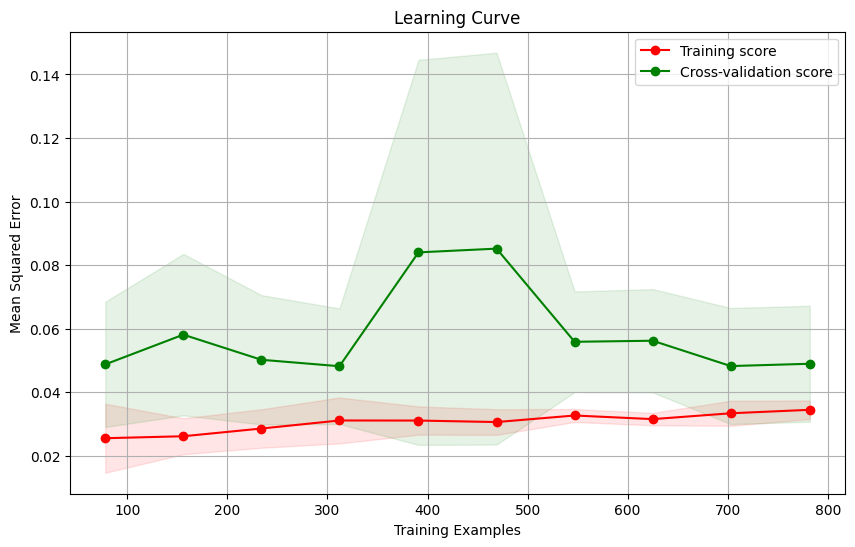

Train Sizes: [ 78 156 234 312 391 469 547 625 703 782]
Train Scores (Mean):
 [0.02554603 0.02616519 0.02859316 0.03112607 0.03110163 0.03063082
 0.03269279 0.03155049 0.03339185 0.03448431]
Train Scores (Std):
 [0.0108583  0.00566333 0.00605024 0.00722198 0.0044425  0.00402888
 0.0020401  0.00195756 0.00394423 0.00291431]
Test Scores (Mean):
 [0.04877411 0.05812739 0.05022402 0.0481974  0.0840196  0.08519477
 0.05588268 0.05621714 0.04824611 0.04897425]
Test Scores (Std):
 [0.01970827 0.02539264 0.02034154 0.01818382 0.0605783  0.06164232
 0.01583252 0.01624941 0.01826614 0.01824504]


In [19]:
import matplotlib.pyplot as plt
train_scores_mean = -np.mean(train_scores, axis=1)  # Average across folds (negate for MSE)
train_scores_std = np.std(train_scores, axis=1)
test_scores_mean = -np.mean(test_scores, axis=1)    # Average across folds (negate for MSE)
test_scores_std = np.std(test_scores, axis=1)

# 6. Plot the Learning Curve
# ---------------------------
plt.figure(figsize=(10, 6))
plt.title("Learning Curve")
plt.xlabel("Training Examples")
plt.ylabel("Mean Squared Error")  # Label appropriately for your metric
plt.grid()

# Plot the mean training scores
plt.plot(train_sizes, train_scores_mean, 'o-', color="r", label="Training score")
# Plot the mean test scores
plt.plot(train_sizes, test_scores_mean, 'o-', color="g", label="Cross-validation score")

# Plot the standard deviation (as shaded areas)
plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                 train_scores_mean + train_scores_std, alpha=0.1, color="r")
plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                 test_scores_mean + test_scores_std, alpha=0.1, color="g")

plt.legend(loc="best")  # Show the legend
plt.show()


# 7. (Optional)  Print raw results:
#--------------------------------------
print("Train Sizes:", train_sizes)
print("Train Scores (Mean):\n", train_scores_mean)
print("Train Scores (Std):\n", train_scores_std)
print("Test Scores (Mean):\n", test_scores_mean)
print("Test Scores (Std):\n", test_scores_std)

In [23]:
alphas = (0.001, 0.01, 0.1, 0.5, 1, 2, 10)
# enumerate through alphas with index and i
for  i in  alphas:    
    lasso = Lasso(alpha = i)
    lasso.fit(X_train_scaled, y_train)
    print(f'Lasso Regression: R^2 score on test set for  lamdbda= {i}, {lasso.score(X_test_scaled, y_test):.3}')


Lasso Regression: R^2 score on test set for  lamdbda= 0.001, 0.0133
Lasso Regression: R^2 score on test set for  lamdbda= 0.01, 0.0189
Lasso Regression: R^2 score on test set for  lamdbda= 0.1, -0.000255
Lasso Regression: R^2 score on test set for  lamdbda= 0.5, -0.000255
Lasso Regression: R^2 score on test set for  lamdbda= 1, -0.000255
Lasso Regression: R^2 score on test set for  lamdbda= 2, -0.000255
Lasso Regression: R^2 score on test set for  lamdbda= 10, -0.000255


In [24]:
X.shape , len(alphas)

((1432, 10), 7)

In [25]:
# plot  alphas

# prepare data for enumerate
coeff_a = np.zeros((len(alphas), X.shape[1]))
train_r_squared = np.zeros(len(alphas))
test_r_squared = np.zeros(len(alphas))

In [26]:
# enumerate through alphas  with index and i
for ind, i in enumerate(alphas):    
    lasso = Lasso(alpha = i)
    lasso.fit(X_train_scaled, y_train)

    coeff_a[ind,:] = lasso.coef_
    train_r_squared[ind] = lasso.score(X_train_scaled, y_train)
    test_r_squared[ind] = lasso.score(X_test_scaled, y_test)

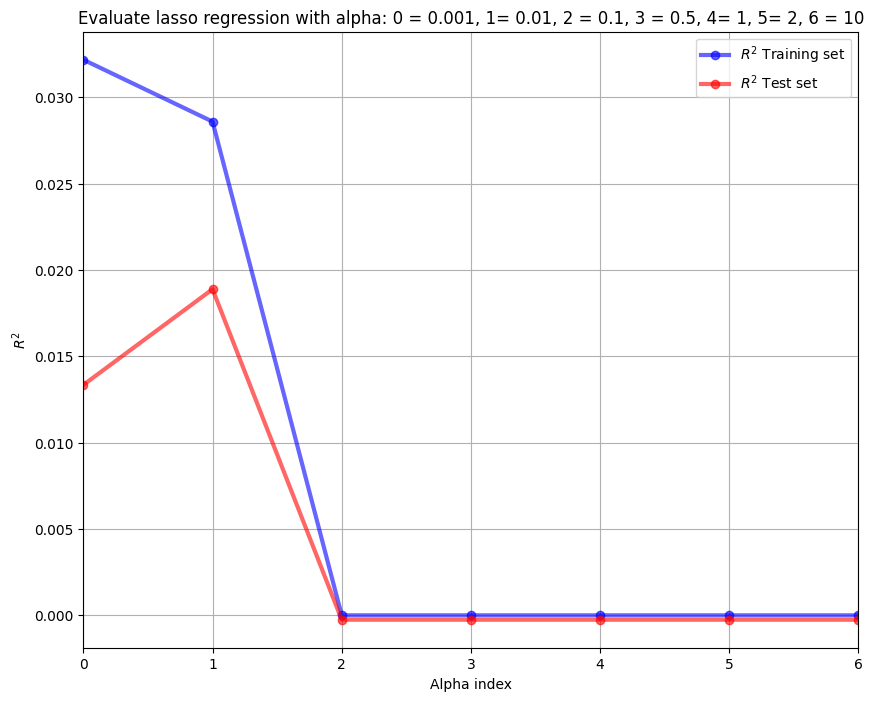

In [30]:
# Plotting
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
plt.plot(train_r_squared, 'bo-', label=r'$R^2$ Training set', alpha=0.6, linewidth=3)
plt.plot(test_r_squared, 'ro-', label=r'$R^2$ Test set',  alpha=0.6, linewidth=3)
plt.xlabel('Alpha index'); plt.ylabel(r'$R^2$')
plt.xlim(0, 6)
plt.title(r'Evaluate lasso regression with alpha: 0 = 0.001, 1= 0.01, 2 = 0.1, 3 = 0.5, 4= 1, 5= 2, 6 = 10')
plt.legend(loc='best')
plt.grid()

In [ ]:
#  Validation_curve   توظيف 

In [31]:
from sklearn.model_selection import validation_curve
from sklearn.linear_model import Ridge
import numpy as np

alphas=np.logspace(-7, 30, 10)
from sklearn.model_selection import validation_curve
train_scores, test_scores = validation_curve(estimator=lasso, 
                                              X=X_train, 
                                              y=y_train,
                                              param_name="alpha" ,
                                              param_range=alphas, 
                                              cv=10
 )

/tmp/ipykernel_2293/1528153738.py:11: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  plt.xlim([0, 0.1])


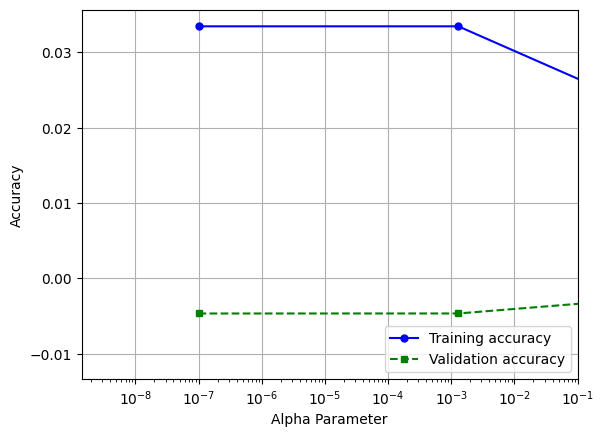

In [32]:
train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
plt.plot(alphas, train_mean, color='blue', marker='o',markersize=5, label='Training accuracy')
plt.plot(alphas, test_mean,color='green', linestyle='--',marker='s', markersize=5,label='Validation accuracy')
plt.grid()
plt.xscale('log')

plt.xlabel('Alpha Parameter')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.xlim([0, 0.1])
plt.show()

In [33]:
lasso = Lasso(alpha=.001).fit(X_train_scaled, y_train)

In [ ]:
# تخطيط التعلّم 
import scikitplot as skplt
skplt.estimators.plot_learning_curve(lasso, X_train, y_train, scoring="r2")  #"neg_mean_absolute_error")

ImportError: cannot import name 'interp' from 'scipy' (/home/codespace/.local/lib/python3.12/site-packages/scipy/__init__.py)